# Evaluation audit: is the adaptive (RL) gain real?

`Adaptive_ETA_Prediction.ipynb` reports that the NLP + Q-learning layer lowers test MAE by **1.65 %** (137.89 → 135.61 min).
This notebook re-checks that claim. It replays the main notebook's own cells (same data generator, DNN, NLP pipeline,
environment and agent), so nothing here is a re-implementation of the method.

**Three problems in the original evaluation protocol**

1. **The test-time correction uses the true arrival time** (main notebook, Cell 15). Each test voyage's delay severity is
   derived from `residual = actual_eta − base_eta`, i.e. from the value being predicted. In training, severity comes from
   the voyage's latent disruption (the simulated captain's log), which is what would actually exist at prediction time.
2. **The Q-learning environment samples from all 1,000 voyages** (Cell 11), so the agent collects rewards from the 200
   test voyages' true arrival times.
3. **Early stopping monitors the test set** (Cell 5), so the DNN's test MAE is selected on the test set itself.

**Leak-free protocol used below**

* Train / validation / test = 640 / 160 / 200 voyages; the test set is the same 200 voyages as in the main notebook.
* Early stopping on the validation split only.
* The Q-learning environment is built from training voyages only.
* Every voyage's severity, train and test, comes from the log matched to its latent disruption, never from its arrival time.
* Five random seeds (the main notebook uses one), because 200 test voyages and a stochastic agent make single runs noisy.

**Methods compared** (all use the same DNN base prediction per seed)

| Method | What it adds to the DNN |
|---|---|
| DNN alone | nothing |
| Constant bias correction | one multiplicative factor learned on training voyages (no NLP) |
| Linear severity correction | `ETA × (1 + a + b·severity)`, `a` and `b` fitted by least squares on training voyages |
| Q-learning (clean) | the original agent, trained on training voyages only |

Runtime: about 1-2 minutes on a laptop CPU.

In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nbformat
import torch
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

MAIN = "Adaptive_ETA_Prediction.ipynb"
SEEDS = [42, 1, 2, 3, 4]          # 42 is the main notebook's seed

# Locate the main notebook's cells by their "Cell N:" header, so this audit always replays the current code.
_main = [c.source for c in nbformat.read(MAIN, as_version=4).cells if c.cell_type == "code"]
def main_cell(n):
    hits = [s for s in _main if f"Cell {n}:" in s.splitlines()[0]]
    assert len(hits) == 1, f"Cell {n} not found exactly once in {MAIN}"
    return hits[0]

# Cells needed to reproduce the original pipeline end to end (plots run but are never saved).
ORIGINAL_CELLS = [1, 2, 3, 4, 5, 7, 8, 10, 11, 12, 13, 15]
print("Replaying main-notebook cells:", ORIGINAL_CELLS)

Replaying main-notebook cells: [1, 2, 3, 4, 5, 7, 8, 10, 11, 12, 13, 15]


## Replay the original pipeline, then evaluate it leak-free

`run_original(seed)` executes the main notebook's cells with the given seed and returns their variables, including the
originally reported MAEs. `clean_eval` then retrains the DNN with proper early stopping and scores all four methods.

In [2]:
def run_original(seed):
    ns = {}
    real_savefig, real_show = plt.savefig, plt.show
    plt.savefig = lambda *a, **k: None          # never overwrite the repository's figures
    plt.show = lambda *a, **k: plt.close("all")
    import contextlib, io
    try:
        with contextlib.redirect_stdout(io.StringIO()):     # the replayed cells' own prints are not needed here
            for n in ORIGINAL_CELLS:
                src = main_cell(n)
                if n == 1:
                    assert "seed          = 42" in src
                    src = src.replace("seed          = 42", f"seed          = {seed}")
                exec(src, ns)
    finally:
        plt.savefig, plt.show = real_savefig, real_show
    return ns


def clean_eval(ns, seed):
    CFG, df, FEATURES = ns["CFG"], ns["df"], ns["FEATURE_COLS"]
    torch.manual_seed(seed); np.random.seed(seed); random.seed(seed)

    idx = np.arange(len(df))
    tr_full, te = train_test_split(idx, test_size=CFG["test_size"], random_state=CFG["seed"])  # same test set as main notebook
    tr, va = train_test_split(tr_full, test_size=0.20, random_state=CFG["seed"])

    X, y = df[FEATURES].values, df[["actual_eta"]].values
    xs, ys = StandardScaler().fit(X[tr]), StandardScaler().fit(y[tr])
    T = lambda a: torch.tensor(a, dtype=torch.float32)
    Xtr, ytr = T(xs.transform(X[tr])), T(ys.transform(y[tr]))
    Xva, yva = T(xs.transform(X[va])), T(ys.transform(y[va]))
    loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(Xtr, ytr),
                                         batch_size=CFG["batch_size"], shuffle=True, drop_last=True)

    # Same architecture and optimiser as the main notebook; early stopping on VALIDATION
    model = ns["ETAModel"](len(FEATURES), CFG)
    opt = torch.optim.Adam(model.parameters(), lr=CFG["lr"])
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=8, factor=0.5)
    best, wait, state = np.inf, 0, None
    for _ in range(CFG["epochs"]):
        model.train()
        for xb, yb in loader:
            opt.zero_grad()
            torch.nn.functional.mse_loss(model(xb), yb).backward()
            opt.step()
        model.eval()
        with torch.no_grad():
            v = torch.nn.functional.mse_loss(model(Xva), yva).item()
        sched.step(v)
        if v < best:
            best, wait, state = v, 0, {k: t.clone() for k, t in model.state_dict().items()}
        else:
            wait += 1
            if wait >= CFG["patience"]:
                break
    model.load_state_dict(state)
    model.eval()

    def base_eta(rows):
        with torch.no_grad():
            return ys.inverse_transform(model(T(xs.transform(X[rows]))).numpy()).ravel()

    # Severity from the log matched to each voyage's latent disruption (what exists at prediction time)
    pool = ns["pool_scores"]
    latent = df["latent_severity"].values
    severity = lambda rows: pool[np.abs(pool[None, :] - latent[rows][:, None]).argmin(axis=1)]

    actual = y.ravel()
    b_tr, b_te, s_tr, s_te = base_eta(tr), base_eta(te), severity(tr), severity(te)
    out = {"DNN alone": mean_absolute_error(actual[te], b_te)}

    ratio = actual[tr] / b_tr - 1                                   # how far off the DNN is, as a fraction
    out["Constant bias correction"] = mean_absolute_error(actual[te], b_te * (1 + np.median(ratio)))

    a, b = np.linalg.lstsq(np.c_[np.ones_like(s_tr), s_tr], ratio, rcond=None)[0]
    out["Linear severity correction"] = mean_absolute_error(actual[te], b_te * (1 + a + b * s_te))

    # The original agent and environment, trained on TRAINING voyages only
    Env, Agent = ns["ETAEnvironment"], ns["QLearningAgent"]
    ns["predict_base_eta"] = lambda f: float(base_eta_from_features(model, xs, ys, f))
    env = Env(df.iloc[tr], CFG)
    agent = Agent(CFG["n_eta_bins"], CFG["n_sev_bins"], len(Env.ACTION_FRACTIONS), CFG)
    for ep in range(1, CFG["n_episodes"] + 1):
        s0 = env.reset()
        act = agent.select_action(s0)
        s1, r, _ = env.step(act)
        agent.update(s0, act, r, s1)
        agent.decay_epsilon(ep)
    adj = [bb * (1 + Env.ACTION_FRACTIONS[agent.best_action((env._eta_bucket(bb), env._sev_bucket(ss)))])
           for bb, ss in zip(b_te, s_te)]
    out["Q-learning (clean)"] = mean_absolute_error(actual[te], adj)
    out["linear a, b"] = (round(float(a), 4), round(float(b), 4))
    return out


def base_eta_from_features(model, xs, ys, features):
    x = torch.tensor(xs.transform(np.array(features, dtype=np.float32).reshape(1, -1)), dtype=torch.float32)
    with torch.no_grad():
        return ys.inverse_transform(model(x).numpy())[0, 0]

In [3]:
rows = []
for seed in SEEDS:
    ns = run_original(seed)
    row = {"seed": seed,
           "Original: DNN (test-set early stopping)": ns["mae_base_eval"],
           "Original: adaptive (as published)": ns["mae_adap_eval"]}
    row.update(clean_eval(ns, seed))
    rows.append(row)
    print(f"seed {seed:>2}: original {row['Original: DNN (test-set early stopping)']:.2f} -> {row['Original: adaptive (as published)']:.2f}"
          f" | clean DNN {row['DNN alone']:.2f}, linear {row['Linear severity correction']:.2f}, Q-learning {row['Q-learning (clean)']:.2f}")

audit = pd.DataFrame(rows)
import os
os.makedirs("results", exist_ok=True)
audit.to_csv("results/evaluation_audit.csv", index=False)
audit.round(2)

C:\Users\riyan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


seed 42: original 137.89 -> 135.61 | clean DNN 153.61, linear 134.22, Q-learning 152.09


seed  1: original 125.06 -> 125.06 | clean DNN 129.97, linear 112.93, Q-learning 137.88


seed  2: original 141.12 -> 133.45 | clean DNN 149.43, linear 149.16, Q-learning 145.15


seed  3: original 164.69 -> 163.52 | clean DNN 175.91, linear 165.90, Q-learning 176.69


seed  4: original 150.61 -> 152.71 | clean DNN 155.41, linear 145.13, Q-learning 145.57


,seed,Original: DNN (test-set early stopping),Original: adaptive (as published),DNN alone,Constant bias correction,Linear severity correction,Q-learning (clean),"linear a, b"
0,42,137.89,135.61,153.61,148.41,134.22,152.09,"(-0.0929, 0.1039)"
1,1,125.06,125.06,129.97,124.14,112.93,137.88,"(-0.0871, 0.1274)"
2,2,141.12,133.45,149.43,156.11,149.16,145.15,"(-0.0777, 0.1131)"
3,3,164.69,163.52,175.91,172.97,165.90,176.69,"(-0.1006, 0.1275)"
4,4,150.61,152.71,155.41,155.64,145.13,145.57,"(-0.0679, 0.1302)"


## Results

MAE is in minutes (lower is better). Gains are paired: each method is compared with the DNN **from the same seed**, because
the absolute MAE moves by about ±16 minutes between seeds, more than any method's effect.

In [4]:
mae_cols = ["Original: DNN (test-set early stopping)", "Original: adaptive (as published)",
            "DNN alone", "Constant bias correction", "Q-learning (clean)", "Linear severity correction"]
summary = audit[mae_cols].agg(["mean", "std"]).T.round(2)
summary.columns = ["MAE mean (min)", "MAE sd (min)"]

gains = pd.DataFrame({
    "Original adaptive vs original DNN (leaky protocol)":
        100 * (audit["Original: DNN (test-set early stopping)"] - audit["Original: adaptive (as published)"]) / audit["Original: DNN (test-set early stopping)"],
    "Constant bias correction": 100 * (audit["DNN alone"] - audit["Constant bias correction"]) / audit["DNN alone"],
    "Q-learning (clean)": 100 * (audit["DNN alone"] - audit["Q-learning (clean)"]) / audit["DNN alone"],
    "Linear severity correction": 100 * (audit["DNN alone"] - audit["Linear severity correction"]) / audit["DNN alone"],
})
gains.index = audit["seed"]
display(summary)
display(gains.round(2).T.assign(mean=gains.mean().round(2), sd=gains.std().round(2)))

opt = (audit["DNN alone"] - audit["Original: DNN (test-set early stopping)"]) / audit["DNN alone"] * 100
print(f"Early stopping on the test set made the DNN look {opt.mean():.1f}% better on average than proper validation does.")
wins = (audit["Linear severity correction"] < audit["Q-learning (clean)"]).sum()
print(f"Linear correction beats clean Q-learning in {wins} of {len(audit)} seeds.")

,MAE mean (min),MAE sd (min)
Original: DNN (test-set early stopping),143.87,14.80
Original: adaptive (as published),142.07,15.64
DNN alone,152.87,16.39
Constant bias correction,151.45,17.73
Q-learning (clean),151.48,14.97
Linear severity correction,141.47,19.60


seed,42,1,2,3,4,mean,sd
Original adaptive vs original DNN (leaky protocol),1.65,0.00,5.43,0.71,-1.39,1.28,2.57
Constant bias correction,3.39,4.49,-4.47,1.67,-0.15,0.99,3.52
Q-learning (clean),0.99,-6.09,2.86,-0.44,6.33,0.73,4.58
Linear severity correction,12.62,13.11,0.18,5.69,6.62,7.64,5.37


Early stopping on the test set made the DNN look 5.8% better on average than proper validation does.
Linear correction beats clean Q-learning in 4 of 5 seeds.


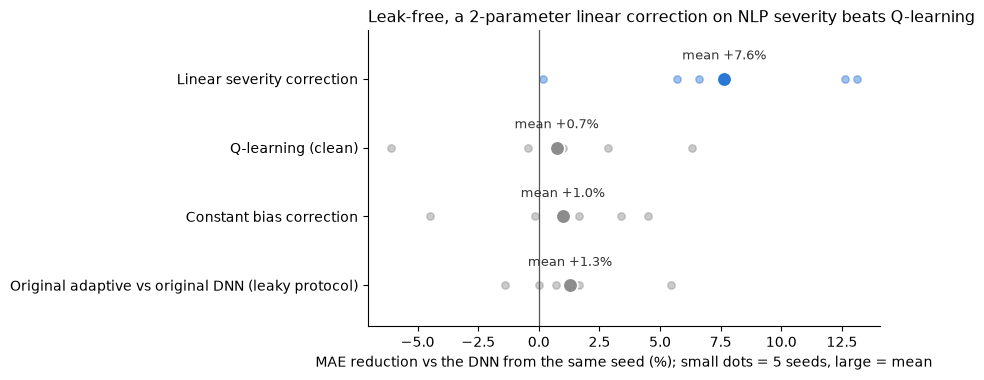

In [5]:
order = ["Original adaptive vs original DNN (leaky protocol)", "Constant bias correction",
         "Q-learning (clean)", "Linear severity correction"]
fig, ax = plt.subplots(figsize=(9, 3.9))
for yi, name in enumerate(order):
    vals = gains[name].values
    colour = "#2a78d6" if name == "Linear severity correction" else "#8c8c8c"
    ax.scatter(vals, np.full(len(vals), yi), s=28, color=colour, alpha=0.45, zorder=2)
    ax.scatter(vals.mean(), yi, s=110, color=colour, zorder=3, edgecolor="white", linewidth=1.2)
    ax.text(vals.mean(), yi + 0.28, f"mean {vals.mean():+.1f}%", ha="center", fontsize=9, color="#333333")
ax.axvline(0, color="#555555", lw=0.9)
ax.set_yticks(range(len(order)), order)
ax.set_ylim(-0.6, len(order) - 0.3)
ax.set_xlabel("MAE reduction vs the DNN from the same seed (%); small dots = 5 seeds, large = mean")
ax.set_title("Leak-free, a 2-parameter linear correction on NLP severity beats Q-learning", loc="left", fontsize=11.5)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
plt.tight_layout()
plt.savefig("figures/fig_evaluation_audit.png", dpi=170, bbox_inches="tight")
plt.show()

## Conclusions

* **The published 1.65 % is a single-seed result.** Re-running the original notebook unchanged with other seeds gives
  gains on both sides of zero (table above).
* **With the three leaks removed, Q-learning gives no reliable improvement** over the DNN: its mean gain is small and the
  spread across seeds covers zero.
* **The NLP severity signal itself is useful.** A two-parameter linear correction on it lowers MAE by several percent on
  average and beats Q-learning in most seeds. The decision is made once per voyage with no next state, so the problem is a
  contextual bandit; a direct regression on severity uses that signal more efficiently than five discrete actions over
  210 states.
* **The DNN's original test MAE was optimistic**, because early stopping selected the epoch with the best test score.

The main notebook is left unchanged so the numbers in `Research_Paper.pdf` remain reproducible; its evaluation cell points
here.